In [1]:
import kagglehub

dataset_path = kagglehub.dataset_download("mrgabrielblins/speaker-recognition-cmu-arctic")

print("Path to dataset files:", dataset_path)

100%|██████████| 1.26G/1.26G [00:18<00:00, 71.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mrgabrielblins/speaker-recognition-cmu-arctic/versions/1


In [2]:
import os

print(dataset_path)
print(os.path.isdir(dataset_path))
print(os.listdir(dataset_path))

/root/.cache/kagglehub/datasets/mrgabrielblins/speaker-recognition-cmu-arctic/versions/1
True
['test_full.csv', 'test', 'train', 'train.csv']


## Get clean dataset that contains audio only

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "train.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mrgabrielblins/speaker-recognition-cmu-arctic",
  file_path)

print("First 5 records:", df.head())

100%|██████████| 335k/335k [00:00<00:00, 119MB/s]

Extracting zip of train.csv...
First 5 records:           id                   file_path  \
0  rxr_a0591  train/rxr/arctic_a0591.wav   
1  rxr_a0403  train/rxr/arctic_a0403.wav   
2  ljm_a0059  train/ljm/arctic_a0059.wav   
3  jmk_a0134  train/jmk/arctic_a0134.wav   
4  rms_b0067  train/rms/arctic_b0067.wav   

                                              speech speaker  
0                     We are both children together.     rxr  
1    His newborn cunning gave him poise and control.     rxr  
2                His immaculate appearance was gone.     ljm  
3                He obeyed the pressure of her hand.     jmk  
4  Below him the shadow was broken into a pool of...     rms  


In [5]:
new_df = df.drop(columns=['id','speech'])
print(new_df.head())

                    file_path speaker
0  train/rxr/arctic_a0591.wav     rxr
1  train/rxr/arctic_a0403.wav     rxr
2  train/ljm/arctic_a0059.wav     ljm
3  train/jmk/arctic_a0134.wav     jmk
4  train/rms/arctic_b0067.wav     rms


# **1.0 Data Exploration and Analysis**
Explore the features/characteristics of the audio data through statistical analysis, listening and audio data visualization.

## **1.1 Staistical Analysis**

> Based on the data exploration and analysis, the dataset contains 12466 audio recordings with sample rate of 16000 Hz. The average audio duration is 3.2s while the longest audio is 7.66s.

In [6]:
print("Missing value: ",sum(new_df.isnull().values))
print("Total audio: ", new_df.count())
print("Dataset: ", len(new_df))


Missing value:  [0 0]
Total audio:  file_path    12466
speaker      12466
dtype: int64
Dataset:  12466


In [7]:
# build the full path
import os, torch, librosa
import matplotlib.pyplot as plt
import librosa.display
import numpy as np
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

new_df["audio_path"] = new_df["file_path"].apply(lambda x: os.path.join(dataset_path, x))
print(new_df.columns)

Using cpu device
Index(['file_path', 'speaker', 'audio_path'], dtype='object')


In [8]:
rate = []
duration = []

for i in tqdm(new_df["audio_path"]):
  y, sr = librosa.load(i)
  rate.append(sr)
  duration.append(librosa.get_duration(y=y, sr=sr))

new_df["rate"] = rate
new_df["duration"] = duration

print(new_df.head())

100%|██████████| 12466/12466 [00:53<00:00, 233.30it/s]

                    file_path speaker  \
0  train/rxr/arctic_a0591.wav     rxr   
1  train/rxr/arctic_a0403.wav     rxr   
2  train/ljm/arctic_a0059.wav     ljm   
3  train/jmk/arctic_a0134.wav     jmk   
4  train/rms/arctic_b0067.wav     rms   

                                          audio_path   rate  duration  
0  /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  2.630068  
1  /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  3.973832  
2  /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  2.059955  
3  /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  2.165079  
4  /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  5.105034  


In [9]:
print(new_df["duration"].describe())

count    12466.000000
mean         3.208184
std          0.916683
min          0.925034
25%          2.554966
50%          3.160000
75%          3.785034
max          7.665079
Name: duration, dtype: float64


## **1.2 Listening to the recordings**
Randomly pick a **small number** of the recordings (e.g. 10 samples) to explore the nature of the data.
Access the features/characteristics of the speakers and potential challenges that might affect the recording quality such as  background noise, overlapping speech and accents.

In [10]:
from IPython.display import Audio
audio_path = new_df.loc[5, "audio_path"]
Audio(audio_path, rate=sr)

## **1.3 Audio Data Visualization**
Visualize the waveform, MFCC, spectogram and PCA of recordings

In [11]:
recording, sr =librosa.load(new_df.loc[5,"audio_path"], sr=None)
recording_2, sr = librosa.load(new_df.loc[12, "audio_path"], sr=None)

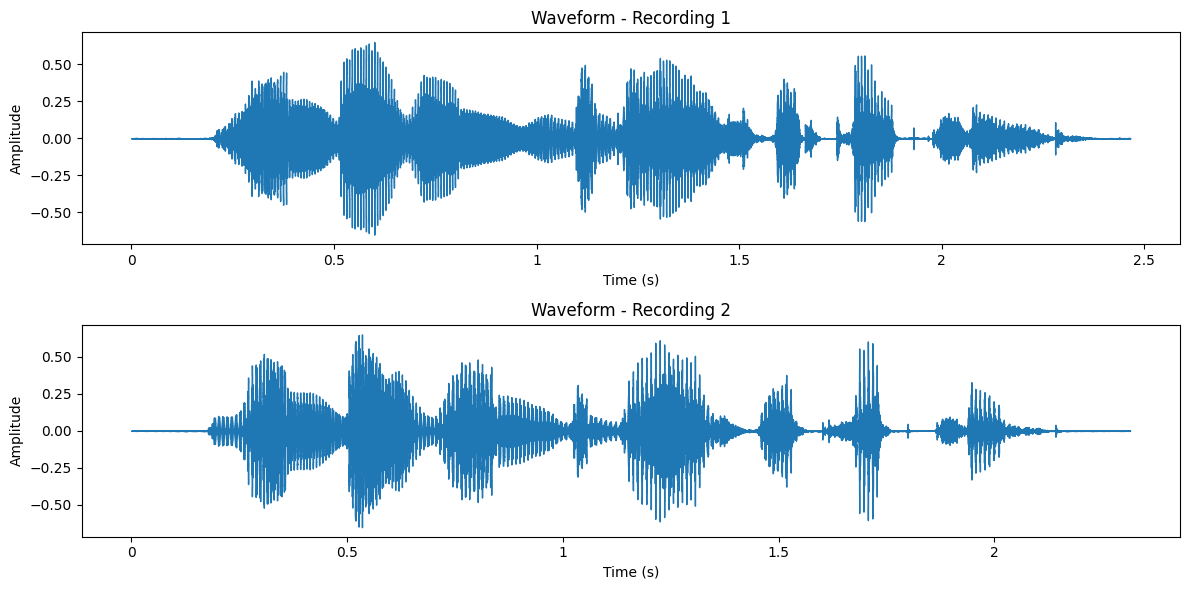

In [12]:

# plot waveform
plt.figure(figsize=(12, 6))

# First waveform
plt.subplot(2, 1, 1)
librosa.display.waveshow(recording, sr=sr)
plt.title("Waveform - Recording 1")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Second waveform
plt.subplot(2, 1, 2)
librosa.display.waveshow(recording_2, sr=sr)
plt.title("Waveform - Recording 2")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


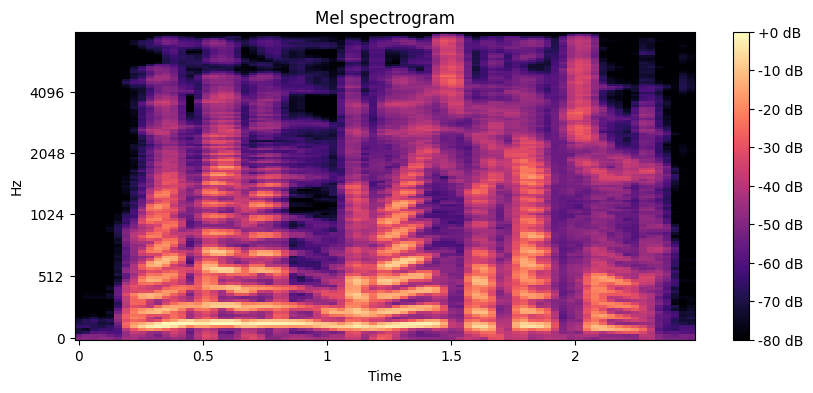

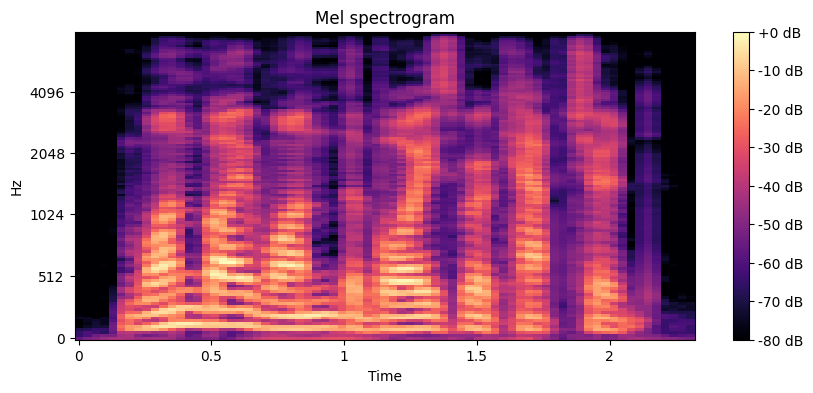

In [13]:

# plot spectrogram
plt.figure(figsize=(10, 4))


# first recording
mel = librosa.feature.melspectrogram(y=recording, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.show()


# second recording
mel = librosa.feature.melspectrogram(y=recording_2, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')

plt.show()

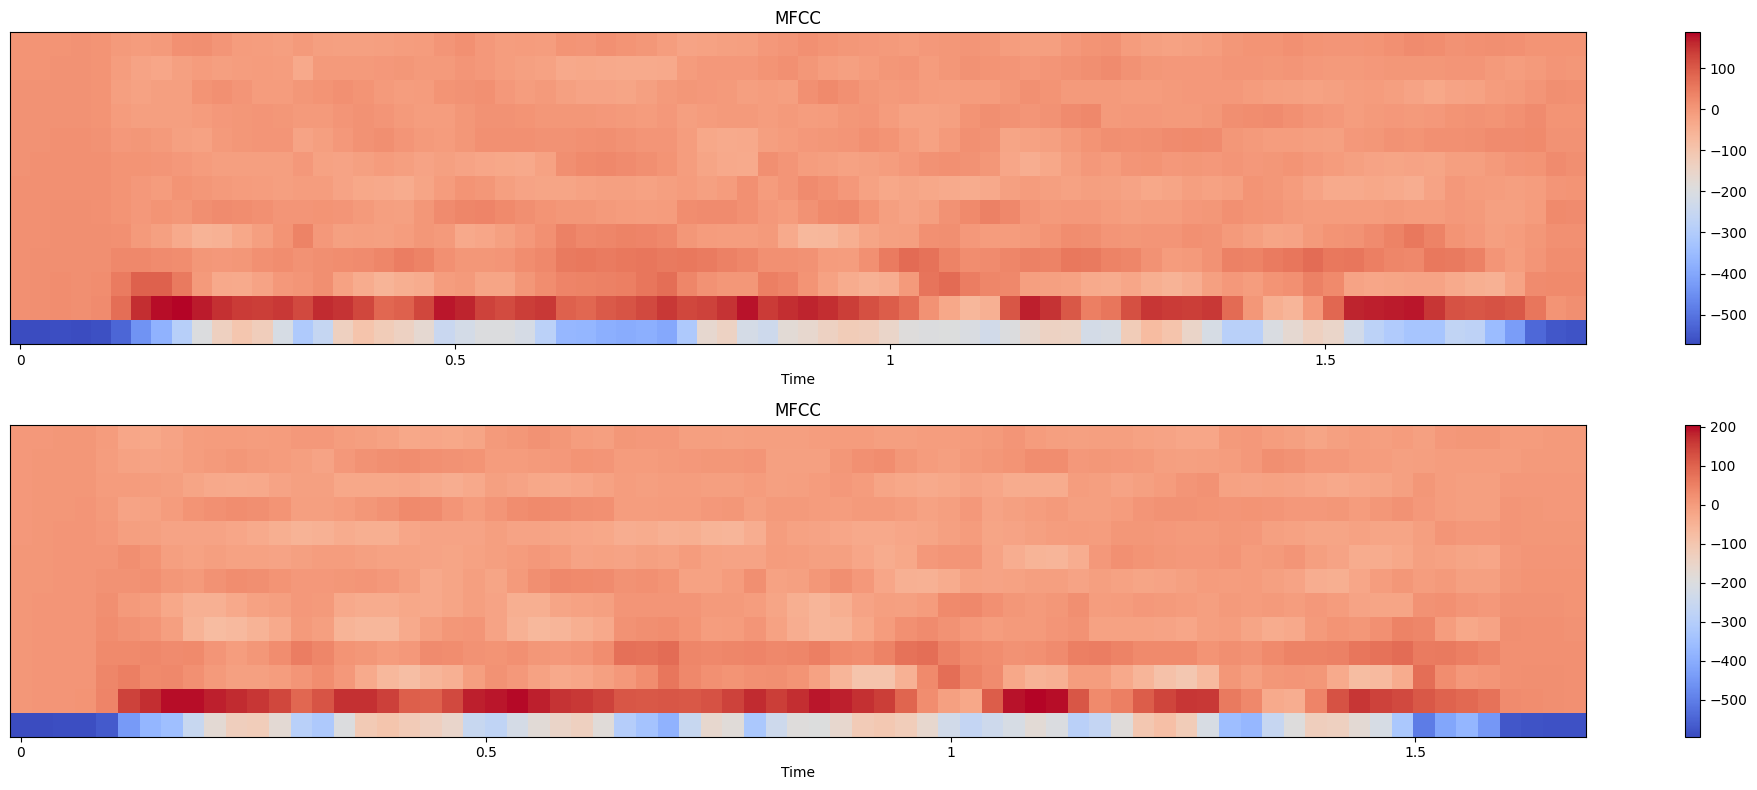

In [14]:
# plot mfcc
mfcc= librosa.feature.mfcc(y=recording, sr=sr, n_mfcc=13)
mfcc_2 = librosa.feature.mfcc(y=recording_2, sr=sr, n_mfcc=13)

plt.figure(figsize=(20,8))

plt.subplot(2,1,1)
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title('MFCC')

plt.subplot(2,1,2)
librosa.display.specshow(mfcc_2, x_axis='time')
plt.colorbar()
plt.title('MFCC')

plt.tight_layout()
plt.show()



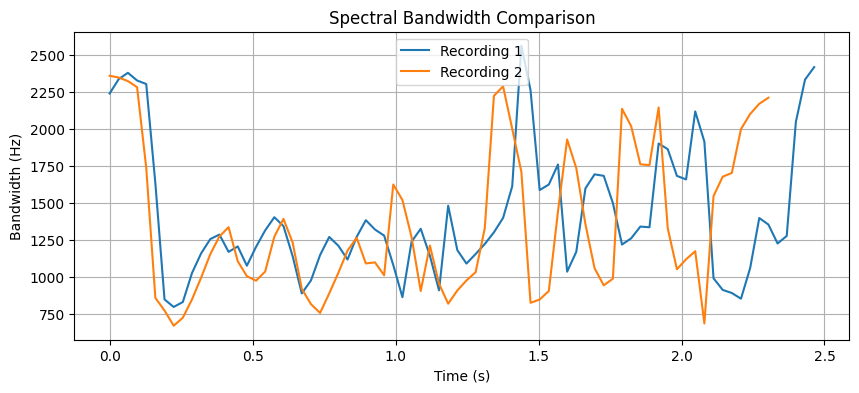

In [15]:
audio, sr =librosa.load(new_df.loc[5,"audio_path"], sr=None)
audio_2, sr = librosa.load(new_df.loc[12, "audio_path"], sr=None)

bandwidth_1 = librosa.feature.spectral_bandwidth(y=audio,sr=sr)

bandwidth_2 = librosa.feature.spectral_bandwidth(y=audio_2,sr=sr)

plt.figure(figsize=(10,4))

plt.plot(librosa.times_like(bandwidth_1, sr=sr),bandwidth_1[0],label="Recording 1")

plt.plot(librosa.times_like(bandwidth_2, sr=sr),bandwidth_2[0],label="Recording 2")

plt.title("Spectral Bandwidth Comparison")
plt.xlabel("Time (s)")
plt.ylabel("Bandwidth (Hz)")
plt.legend()
plt.grid()
plt.show()

In [16]:
import numpy as np
import librosa

X = []

for path in new_df["audio_path"]:

    y, sr = librosa.load(path, sr=None)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    # Mean and standard deviation
    feature = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1)
    ])

    X.append(feature)

X = np.array(X)

print(X.shape)

(12466, 26)


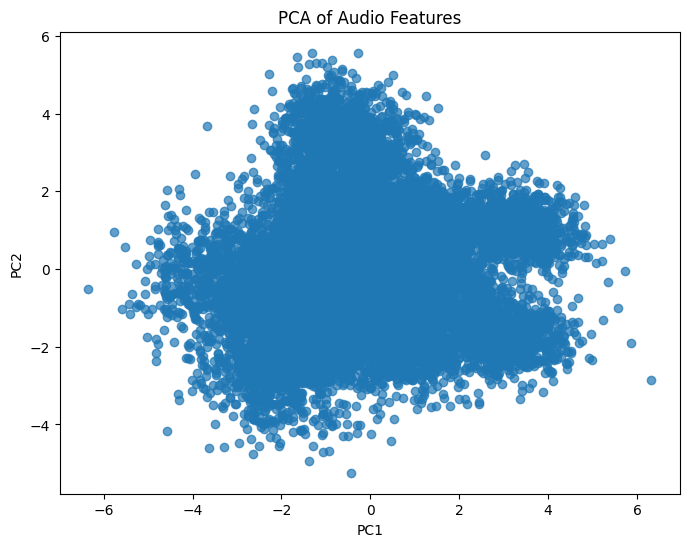

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Audio Features")
plt.show()

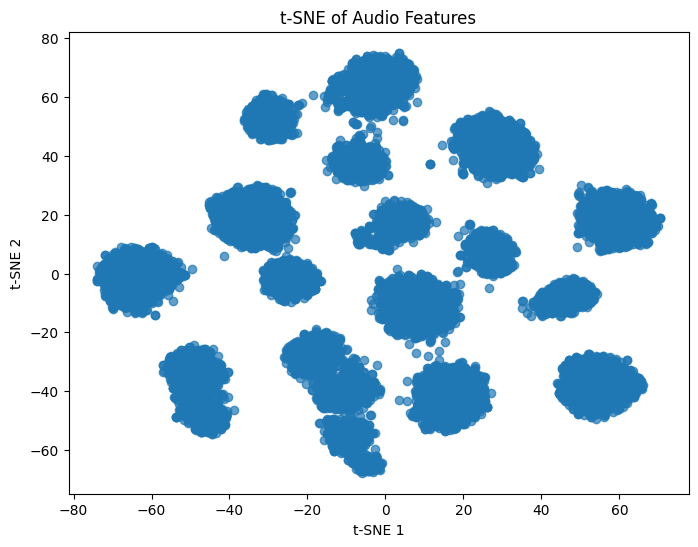

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Audio Features")
plt.show()

# **2.0 Proposed Solution**

Experiment on different embedding and clustering models to figure out the best suit solution.


## 2.1 Preprocessing

Preprocess the recordings using Voice Activation Detection (VAD)

In [19]:
# Preprocess the recodings

def remove_silence(audio_path, top_db=30):

    y, sr = librosa.load(audio_path, sr=16000, mono=True)

    # Remove silence
    y_trimmed, index = librosa.effects.trim( y, top_db=top_db)

    original_duration = len(y) / sr
    trimmed_duration = len(y_trimmed) / sr

    return {
        "audio_path": audio_path,
        "sample_rate": sr,
        "original_duration": original_duration,
        "trimmed_duration": trimmed_duration,
        "audio": y_trimmed
    }

In [20]:
import pandas as pd

results = []

for _, row in new_df.iterrows():

    result = remove_silence(row["audio_path"])

    # Copy all metadata from new_df
    record = row.to_dict()

    record["sample_rate"] = result["sample_rate"]
    record["original_duration"] = result["original_duration"]
    record["trimmed_duration"] = result["trimmed_duration"]
    record["audio"] = result["audio"]

    results.append(record)

vad_df = pd.DataFrame(results)

vad_df.head()

,file_path,speaker,audio_path,rate,duration,sample_rate,original_duration,trimmed_duration,audio
0,train/rxr/arctic_a0591.wav,rxr,/root/.cache/kagglehub/datasets/mrgabrielblins...,22050,2.630068,16000,2.630063,1.504,"[-0.007019043, -0.0054016113, -0.0054016113, -..."
1,train/rxr/arctic_a0403.wav,rxr,/root/.cache/kagglehub/datasets/mrgabrielblins...,22050,3.973832,16000,3.973813,2.752,"[-0.00024414062, 0.0017089844, 0.0014343262, 0..."
2,train/ljm/arctic_a0059.wav,ljm,/root/.cache/kagglehub/datasets/mrgabrielblins...,22050,2.059955,16000,2.059938,1.760,"[-0.0014953613, -0.0024719238, -0.004852295, -..."
3,train/jmk/arctic_a0134.wav,jmk,/root/.cache/kagglehub/datasets/mrgabrielblins...,22050,2.165079,16000,2.165062,1.952,"[-0.0018615723, -0.0033874512, -0.0035705566, ..."
4,train/rms/arctic_b0067.wav,rms,/root/.cache/kagglehub/datasets/mrgabrielblins...,22050,5.105034,16000,5.105000,4.896,"[0.000579834, 0.000579834, 0.00061035156, 0.00..."


In [21]:
short_audio = vad_df[vad_df["trimmed_duration"] < 1]

print("Number of recordings < 1 sec:",len(short_audio))

clean_df = vad_df[vad_df["trimmed_duration"] >= 1].reset_index(drop=True)
print("Number of recordings before:", len(new_df))
print("Number of recordings after: ",len(clean_df))

Number of recordings < 1 sec: 29
Number of recordings before: 12466
Number of recordings after:  12437


In [22]:
print(clean_df)

                        file_path speaker  \
0      train/rxr/arctic_a0591.wav     rxr   
1      train/rxr/arctic_a0403.wav     rxr   
2      train/ljm/arctic_a0059.wav     ljm   
3      train/jmk/arctic_a0134.wav     jmk   
4      train/rms/arctic_b0067.wav     rms   
...                           ...     ...   
12432  train/gka/arctic_a0140.wav     gka   
12433  train/ahw/arctic_a0151.wav     ahw   
12434  train/rxr/arctic_a0508.wav     rxr   
12435  train/ksp/arctic_a0577.wav     ksp   
12436  train/bdl/arctic_b0051.wav     bdl   

                                              audio_path   rate  duration  \
0      /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  2.630068   
1      /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  3.973832   
2      /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  2.059955   
3      /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  2.165079   
4      /root/.cache/kagglehub/datasets/mrgabrielblins...  22050  5.105034 

## 2.2 Audio Embedding
Use embedding to extract voices characteristics and encode audio in the space.

In [23]:
!pip install speechbrain torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 55.6 MB/s eta 0:00:00


In [24]:
import os
import torch
import torchaudio
import numpy as np
import pandas as pd

from speechbrain.inference.speaker import EncoderClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/ecapa"
)

classifier = classifier.to(device)

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


cpu


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


embedding_model.ckpt: reconstructing file:   0%|          |  0.00B / 83.3MB            

...

classifier.ckpt: reconstructing file:   0%|          |  0.00B / 5.53MB            

classifier.ckpt: downloading bytes:           |  0.00B            

INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


In [25]:
import torchaudio
import torch

def extract_embedding(audio_path, classifier, device):

    signal, sr = torchaudio.load(audio_path)

    # Convert stereo to mono if necessary
    if signal.shape[0] > 1:
        signal = signal.mean(dim=0, keepdim=True)

    signal = signal.to(device)

    with torch.no_grad():
        embedding = classifier.encode_batch(signal)

    return embedding.squeeze().cpu().numpy()

In [26]:
from tqdm.auto import tqdm
import numpy as np

embeddings = []

for path in tqdm(clean_df["audio_path"],total=len(clean_df),desc="Extracting ECAPA embeddings"):
    emb = extract_embedding(path, classifier, device)
    embeddings.append(emb)

embeddings = np.vstack(embeddings)

print(embeddings.shape)

Extracting ECAPA embeddings:   0%|          | 0/12437 [00:00<?, ?it/s]

(12437, 192)


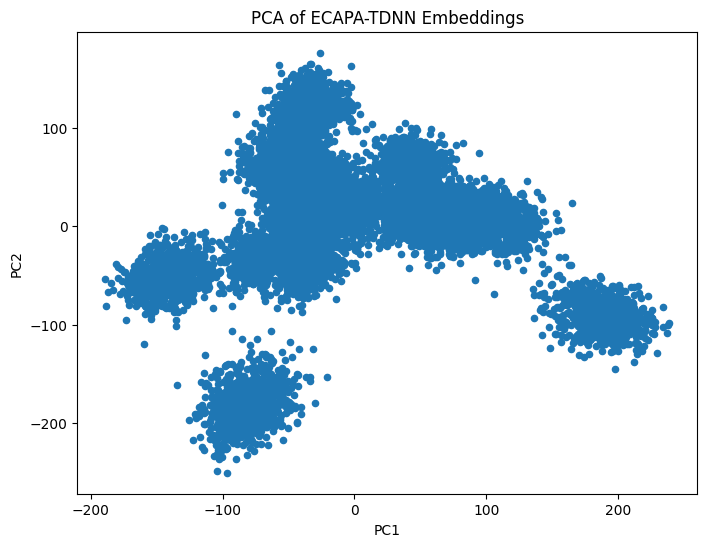

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of ECAPA-TDNN Embeddings")
plt.show()

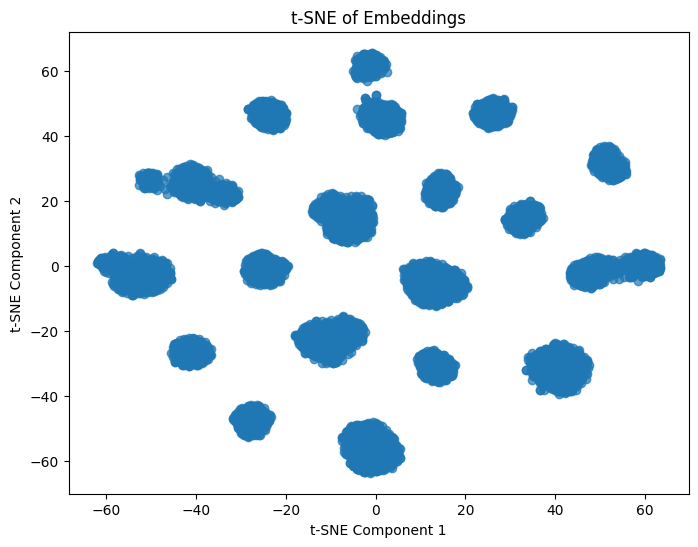

In [28]:
from sklearn.manifold import TSNE

tsne = TSNE( n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    alpha=0.7
)

plt.title("t-SNE of Embeddings")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

In [29]:
# normalise the audio data
from sklearn.preprocessing import normalize

embeddings_norm = normalize(embeddings, norm="l2")

## 2.3 Train model
Use agglomerative, k-means and spectral clustering model

In [30]:
#Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=18,
    linkage="complete",
    metric="cosine"
)

agg_labels = agg.fit_predict(embeddings_norm)

print(np.unique(agg_labels))

clean_df["agg_labels"] = agg_labels

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [31]:
#k-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=18,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(embeddings_norm)

print(np.unique(kmeans_labels))

clean_df["KMeans"] = kmeans_labels

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [32]:
# Spectral Clustering
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=18,
    affinity="nearest_neighbors",  #experiment with different affinity
    random_state=42
)

spectral_labels = spectral.fit_predict(embeddings_norm)

print(np.unique(spectral_labels))

clean_df["Spectral"] = spectral_labels

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


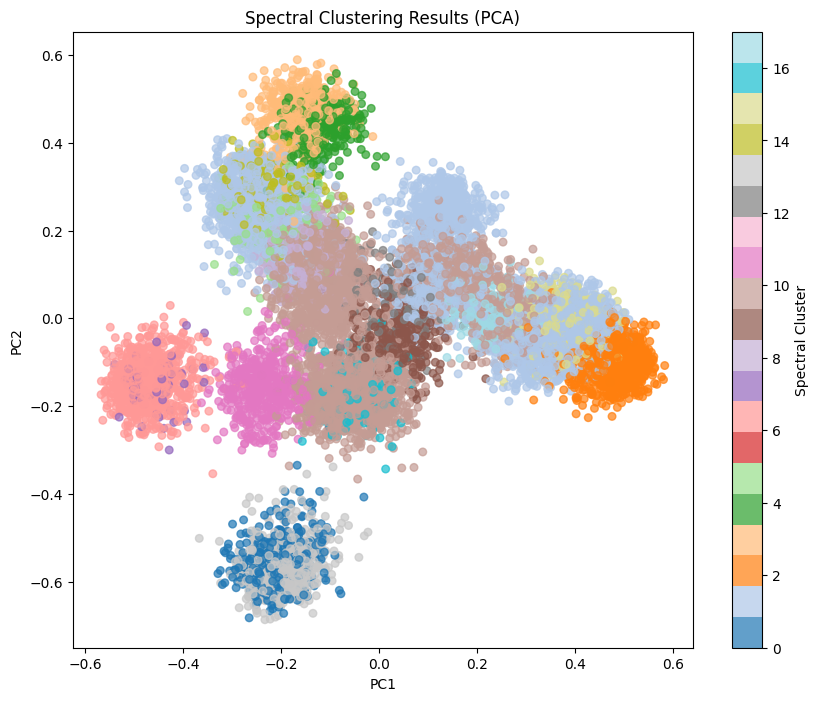

In [54]:
# view the clusters of each model using t-SNE or PCA

pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(embeddings_norm)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1],
    c=spectral_labels,
    cmap="tab20",
    alpha=0.7,
    s=30
)

plt.colorbar(label="Spectral Cluster")
plt.title("Spectral Clustering Results (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

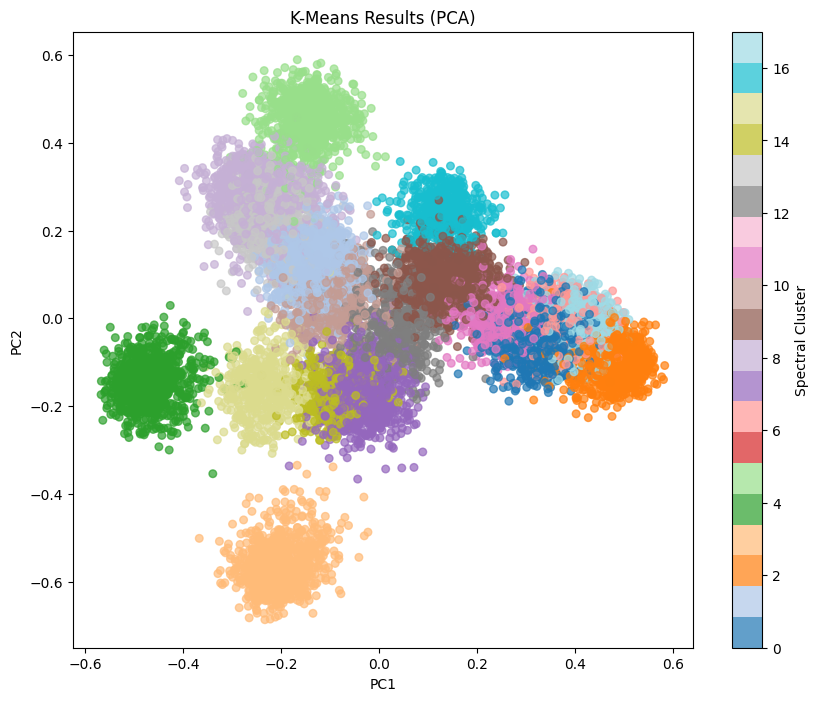

In [55]:


pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(embeddings_norm)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1],
    c=kmeans_labels,
    cmap="tab20",
    alpha=0.7,
    s=30
)

plt.colorbar(label="Spectral Cluster")
plt.title("K-Means Results (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

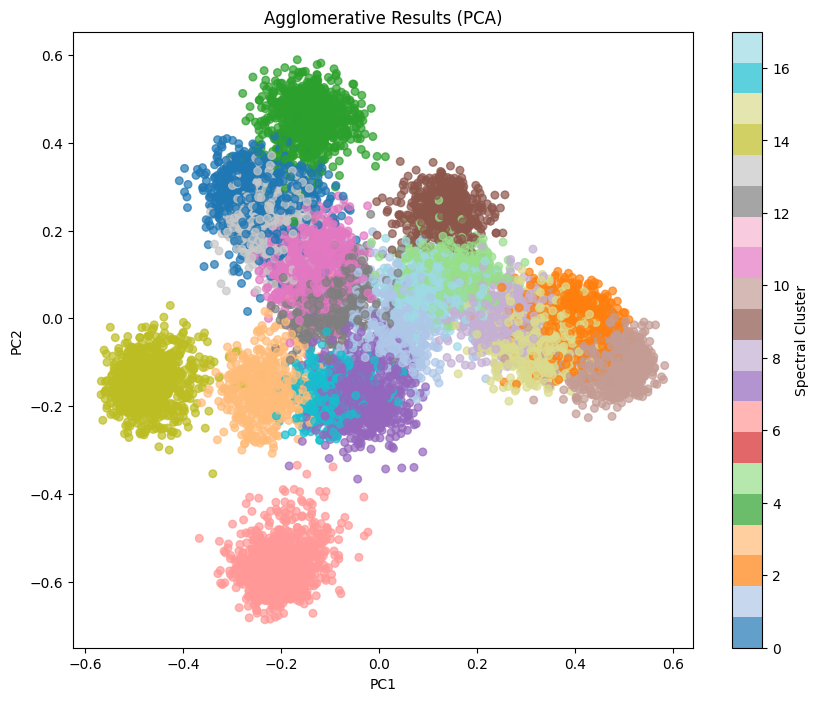

In [56]:


pca = PCA(n_components=2)

embedding_pca = pca.fit_transform(embeddings_norm)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_pca[:,0],
    embedding_pca[:,1],
    c=agg_labels,
    cmap="tab20",
    alpha=0.7,
    s=30
)

plt.colorbar(label="Spectral Cluster")
plt.title("Agglomerative Results (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

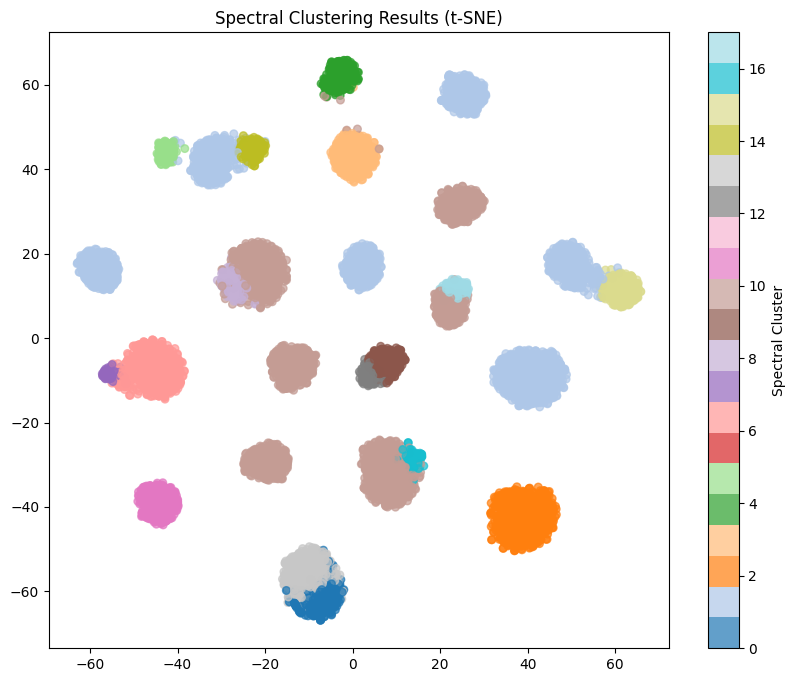

In [51]:

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedding_tsne = tsne.fit_transform(embeddings_norm)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_tsne[:,0],
    embedding_tsne[:,1],
    c=spectral_labels,
    cmap="tab20",
    alpha=0.7,
    s=30
)

plt.colorbar(label="Spectral Cluster")
plt.title("Spectral Clustering Results (t-SNE)")
plt.show()

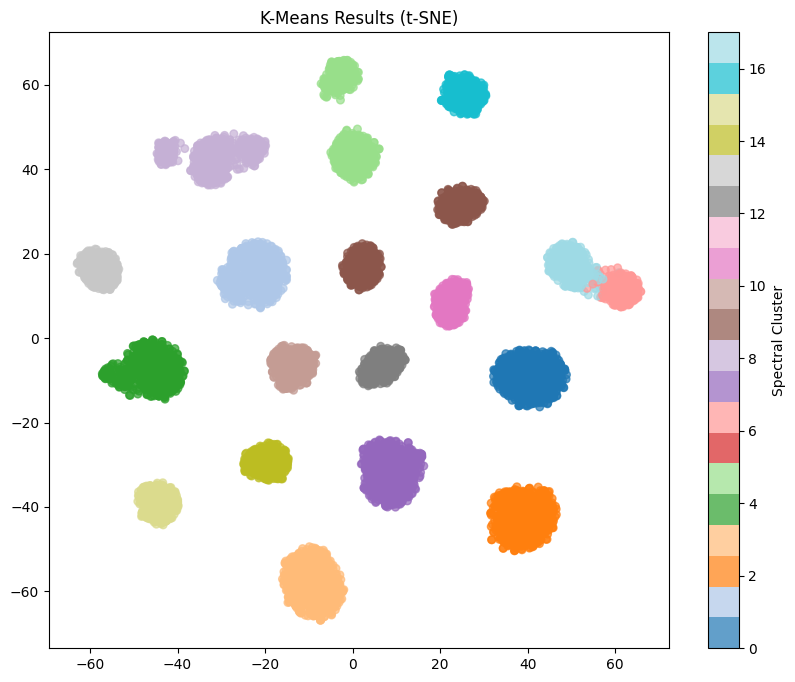

In [52]:

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedding_tsne = tsne.fit_transform(embeddings_norm)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_tsne[:,0],
    embedding_tsne[:,1],
    c=kmeans_labels,
    cmap="tab20",
    alpha=0.7,
    s=30
)

plt.colorbar(label="Spectral Cluster")
plt.title("K-Means Results (t-SNE)")
plt.show()

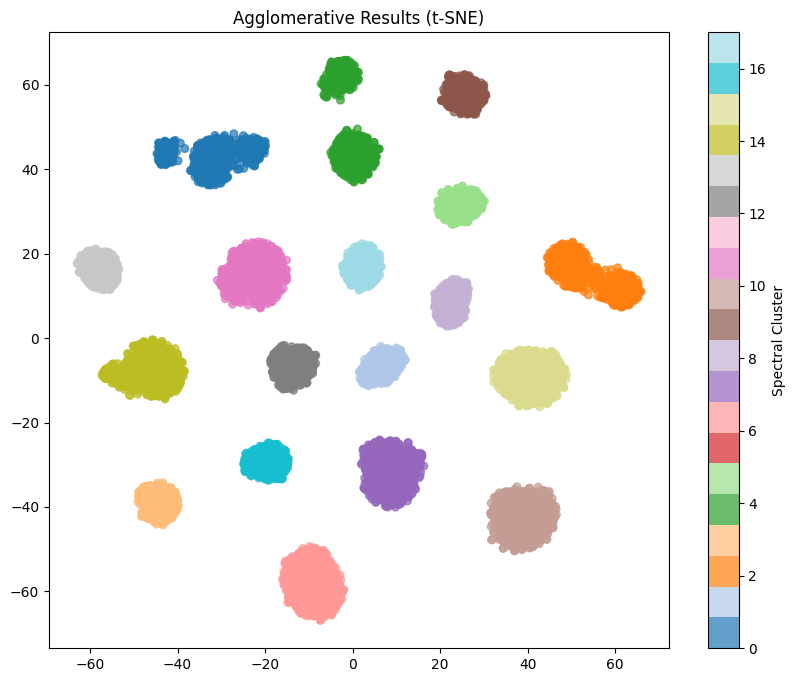

In [53]:

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedding_tsne = tsne.fit_transform(embeddings_norm)

plt.figure(figsize=(10,8))

plt.scatter(
    embedding_tsne[:,0],
    embedding_tsne[:,1],
    c=agg_labels,
    cmap="tab20",
    alpha=0.7,
    s=30
)

plt.colorbar(label="Spectral Cluster")
plt.title("Agglomerative Results (t-SNE)")
plt.show()

PCA showed little visual difference between the three clustering methods, whereas t-SNE suggested that Agglomerative Clustering produced more distinct clusters with less apparent overlap.

# Evaluation
Evalute the model using Silhouette Score (higher), Davies–Bouldin Index (lower) and Calinski–Harabasz Index (higher).

In [34]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [35]:
def evaluate_clustering(X, labels, name):
    print(f"\n{name}")
    print( "Silhouette Score:", silhouette_score(X, labels))
    print("Davies-Bouldin Index:",davies_bouldin_score(X, labels))
    print("Calinski-Harabasz Index:",calinski_harabasz_score(X, labels))

In [37]:
evaluate_clustering(embeddings_norm, agg_labels,"Agglomerative")
evaluate_clustering(embeddings_norm, kmeans_labels,"K-Means")
evaluate_clustering(embeddings_norm, spectral_labels, "Spectral")


Agglomerative
Silhouette Score: 0.33086923
Davies-Bouldin Index: 1.2744529957858466
Calinski-Harabasz Index: 1126.7749

K-Means
Silhouette Score: 0.3123882
Davies-Bouldin Index: 1.4763457624149128
Calinski-Harabasz Index: 1080.45

Spectral
Silhouette Score: 0.020130225
Davies-Bouldin Index: 2.8815407377981828
Calinski-Harabasz Index: 365.11118


Agglomerative Clustering achieved the best overall performance, with the highest Silhouette Score and Calinski–Harabasz Index, and the lowest Davies–Bouldin Index. Now, we will perform testing on the different clustering model.

# Testing on the model

This dataset contains ground truth of speaker labels. The clustering model is evaluated on an unseen recording by checking the assigned cluster with the actuak speaker with the recording's actual speaker.

In [83]:
import kagglehub

dataset_path = kagglehub.dataset_download("mrgabrielblins/speaker-recognition-cmu-arctic")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'speaker-recognition-cmu-arctic' dataset.
Path to dataset files: /kaggle/input/speaker-recognition-cmu-arctic


In [84]:
file_path = "test_full.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mrgabrielblins/speaker-recognition-cmu-arctic",
  file_path)
print("First 5 records:", df.head())

Using Colab cache for faster access to the 'speaker-recognition-cmu-arctic' dataset.
First 5 records:                    id                    file_path  \
0  OELV49874079341496  test/OELV49874079341496.wav   
1  ELDT67178766030957  test/ELDT67178766030957.wav   
2  GWMS82652863581753  test/GWMS82652863581753.wav   
3  UAPD90278002373588  test/UAPD90278002373588.wav   
4  IHIY50549582963537  test/IHIY50549582963537.wav   

                                                         speech speaker  
0                 What was the object of your little sensation.     aew  
1  He had no excuse for the feelings which were aroused in him.     eey  
2                                      I'll see to poor Hughie.     awb  
3                                        Then came my boy code.     jmk  
4               We must give ourselves and not our money alone.     clb  


In [85]:
test_df = df.drop(columns=['id','speech'])
print(test_df.head())

                     file_path speaker
0  test/OELV49874079341496.wav     aew
1  test/ELDT67178766030957.wav     eey
2  test/GWMS82652863581753.wav     awb
3  test/UAPD90278002373588.wav     jmk
4  test/IHIY50549582963537.wav     clb


In [86]:
test_df["audio_path"] = test_df["file_path"].apply(lambda x: os.path.join(dataset_path, x))
print(test_df.columns)


Index(['file_path', 'speaker', 'audio_path'], dtype='object')


In [139]:
from IPython.display import Audio
recording = test_df.loc[1, "audio_path"]
Audio(recording, rate=sr)

In [143]:
print(test_df.loc[1,"speaker"])

eey


In [140]:
kmeans_predict = kmeans.predict(extract_embedding(recording, classifier, device).reshape(1, -1))
print('KMeans prediction: ', kmeans_predict)

KMeans prediction:  [9]


In [141]:
pd.set_option('display.max_colwidth', None)
cluster = clean_df[clean_df['KMeans']== 9]
print(cluster['speaker'])

2        ljm
14       ljm
27       eey
49       ljm
57       ljm
        ... 
12412    ljm
12420    eey
12427    ljm
12428    ljm
12430    eey
Name: speaker, Length: 941, dtype: object


In [142]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

cluster_centers = []

for cluster_id in np.unique(agg_labels):
    cluster_embeddings = embeddings_norm[agg_labels == cluster_id]
    centroid = cluster_embeddings.mean(axis=0)
    cluster_centers.append(centroid)

cluster_centers = np.array(cluster_centers)
new_embedding = extract_embedding(recording, classifier, device)

new_embedding = new_embedding / np.linalg.norm(new_embedding)

similarities = cosine_similarity(
    new_embedding.reshape(1, -1),
    cluster_centers
)

predicted_cluster_agg = np.argmax(similarities)

print("Assigned cluster:", predicted_cluster_agg)

pd.set_option('display.max_colwidth', None)
cluster = clean_df[clean_df['agg_labels']== predicted_cluster_agg]
print(cluster['speaker'])

Assigned cluster: 17
27       eey
62       eey
66       eey
70       eey
103      eey
        ... 
12329    eey
12389    eey
12411    eey
12420    eey
12430    eey
Name: speaker, Length: 472, dtype: object


In [144]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

spectral_centers = []

for cluster_id in np.unique(spectral_labels):
    cluster_embeddings = embeddings_norm[spectral_labels == cluster_id]
    centroid = cluster_embeddings.mean(axis=0)
    spectral_centers.append(centroid)

spectral_centers = normalize(np.array(spectral_centers))

new_embedding = extract_embedding(recording, classifier, device)
new_embedding_norm = normalize(
    new_embedding.reshape(1, -1)
)

similarities = cosine_similarity(
    new_embedding_norm,
    spectral_centers
)

predicted_cluster_spectral = np.argmax(similarities)

print("New recording belongs to Spectral cluster:", predicted_cluster_spectral)

pd.set_option('display.max_colwidth', None)
cluster = clean_df[clean_df['Spectral']== predicted_cluster_spectral]
print(cluster['speaker'])

New recording belongs to Spectral cluster: 1
5        gka
16       lnh
22       gka
24       slp
26       awb
        ... 
12419    lnh
12420    eey
12422    lnh
12430    eey
12432    gka
Name: speaker, Length: 3378, dtype: object
